# Candidate Test 2022 Analysis Part 2

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2). Consider normalizing the data or performing similar scaling transformations as needed.

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:

- An analysis/description of which questions are most crucial concerning their placement on the axes.
- Average positions of parties concerning each question, preferably with accompanying plots of each (or selected) question.
- A clustering analysis where you attempt various cluster numbers, which would correspond to different parties. Discuss whether there is room for more clusters/parties or if a reduction is needed. Make sure you cover: **K-Means, Hierarchical clustering, and DBSCAN.**
- An overview of the political landscape of the elected candidates, highlighting which members agree or disagree the most and which parties or party members have significant disagreements.
- Feel free to explore further and remember that preprocessing, methodology, and evaluation metrics are not mentioned explicitly, but are implicitly assumed.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



In [72]:
import pandas as pd

alldata = pd.read_excel('alldata.xlsx')
drdata = pd.read_excel('drdata.xlsx')
drq = pd.read_excel('drq.xlsx')
electeddata = pd.read_excel('electeddata.xlsx')
tv2data = pd.read_excel('tv2data.xlsx')
tv2q = pd.read_excel('tv2q.xlsx')

questions = alldata.drop(['navn', 'parti', 'storkreds', 'alder'], axis = 'columns') #check that this is the same format in the other projects

# cleans up format so I can squash question sets together
tv2q.rename(columns = {'id': 'ID', 'question' : 'Question'}, inplace = True)
questions_text = pd.concat([drq, tv2q], ignore_index = True)
questions_text = questions_text[['ID', 'Question']]
questions_text.set_index('ID')

,Question
ID,
530,Danmark skal bruge flere penge på at styrke to...
531,Der skal indføres en særlig skat på de allerhø...
533,Kriminalitet begået i udsatte boligområder ska...
534,På sigt skal Danmark meldes ud af EU
535,"Det er fornuftigt, at Danmark i de kommende år..."
537,"Det er okay, at den økonomiske ulighed stiger,..."
538,Forældres indkomst skal være et af kriterierne...
540,Det skal være muligt at tjene penge på at driv...
541,Der skal indføres skat på fortjenesten ved sal...


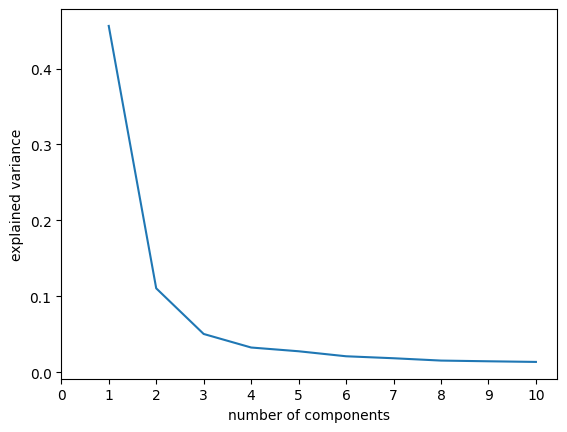

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ratios = eigenvalues, components = eigenvectors

pca = PCA(n_components = 10)
questions_pc = pca.fit_transform(questions)

plt.plot(list(range(1, 1 + len(pca.explained_variance_ratio_))), pca.explained_variance_ratio_)
plt.xlabel('number of components')
plt.ylabel('explained variance')
plt.xticks(np.arange(0, 1 + len(pca.explained_variance_ratio_), step = 1))
plt.show()


2 or 3 components seem best here. A traditional political alignment chart has 2 dimensions, so I'll pick that.

In [74]:
pca2 = pd.DataFrame(pca.components_[0:2]).T
pca2.columns = ['PC1', 'PC2']
sorted_pca2 = pca2.abs().sort_values(by = ['PC1', 'PC2'], ascending = False).head()

for idx in sorted_pca2.index:
    question_text = questions_text.loc[idx, 'Question']
    print(f"Q# {questions_text['ID'].iloc[idx]}: {question_text}")


Q# 531: Der skal indføres en særlig skat på de allerhøjeste indkomster
Q# 550: Der skal indføres kvoter, der sikrer mindst 30 procent kvinder i virksomheders bestyrelser
Q# 3b: Ulandsbistanden bør hæves.
Q# 537: Det er okay, at den økonomiske ulighed stiger, så længe danskerne generelt bliver rigere
Q# 543: Det er en god idé, at dagpengesatsen for nyuddannede er sat ned


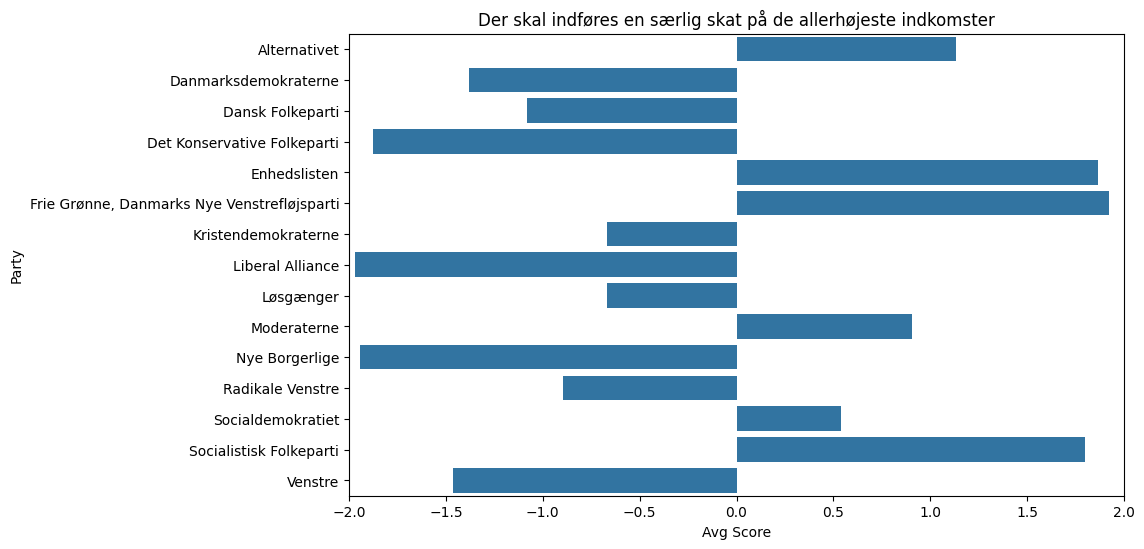

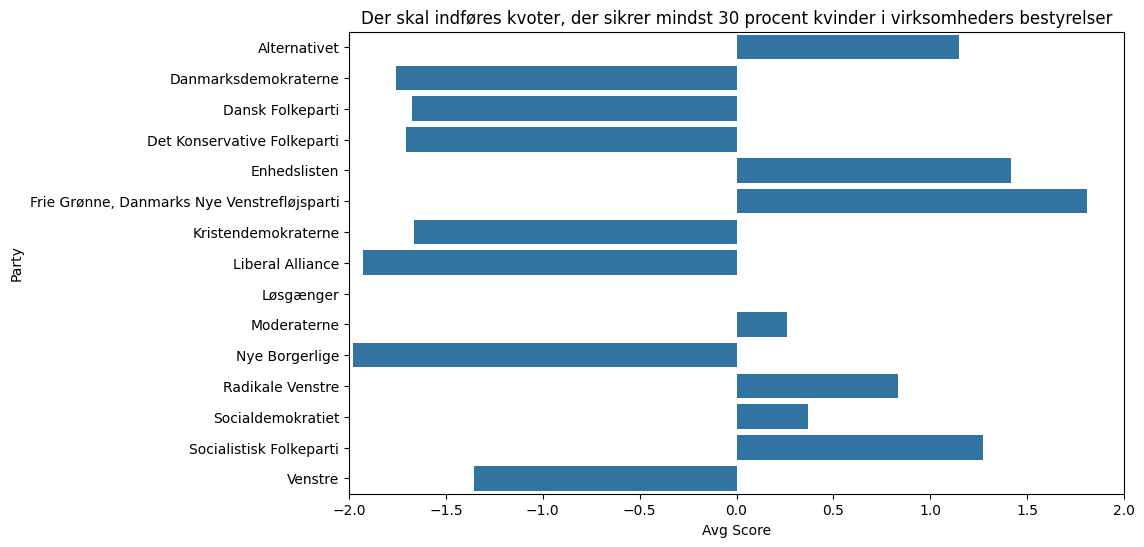

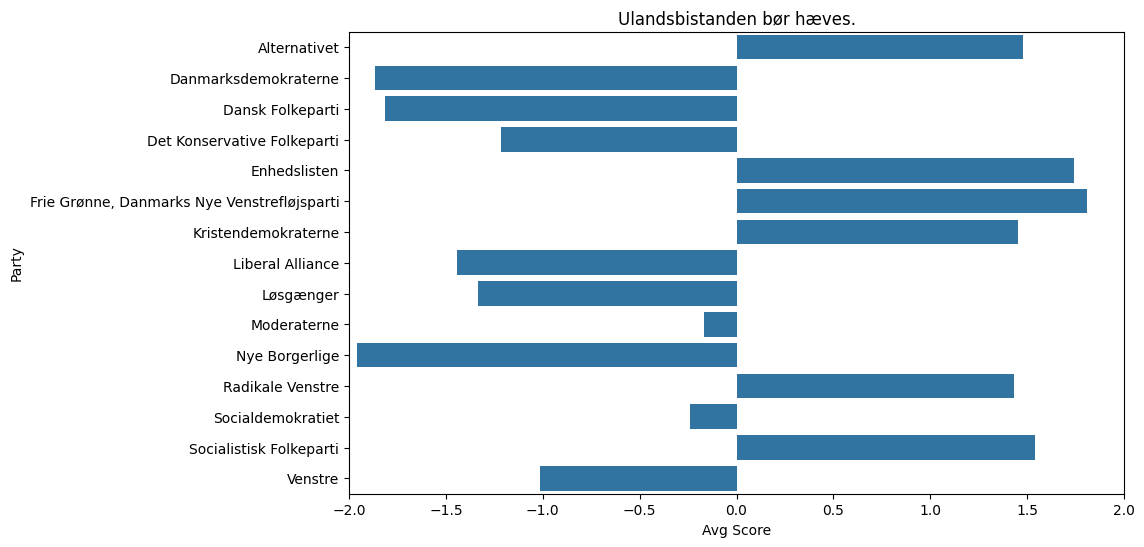

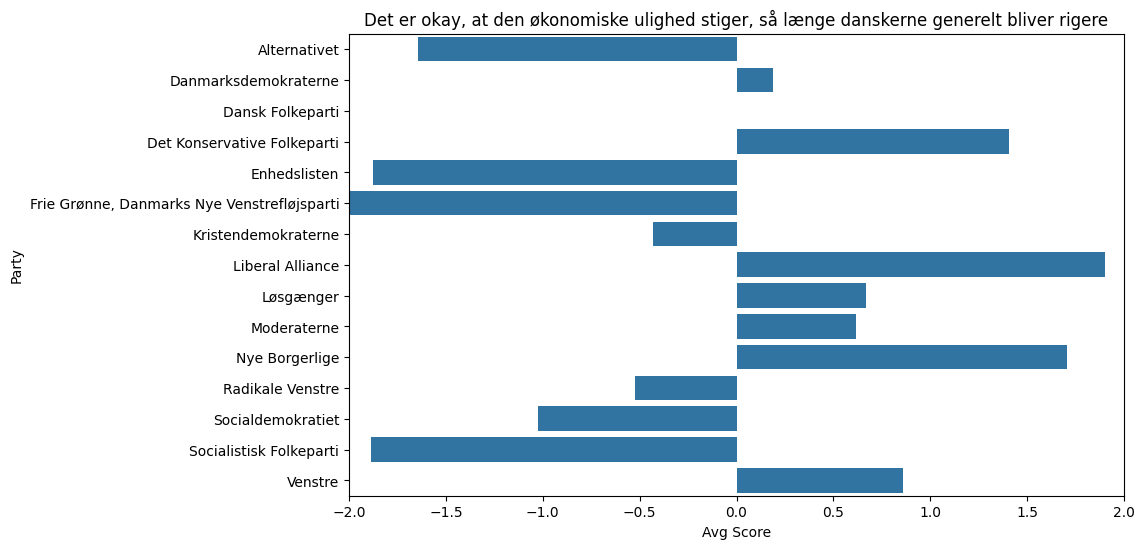

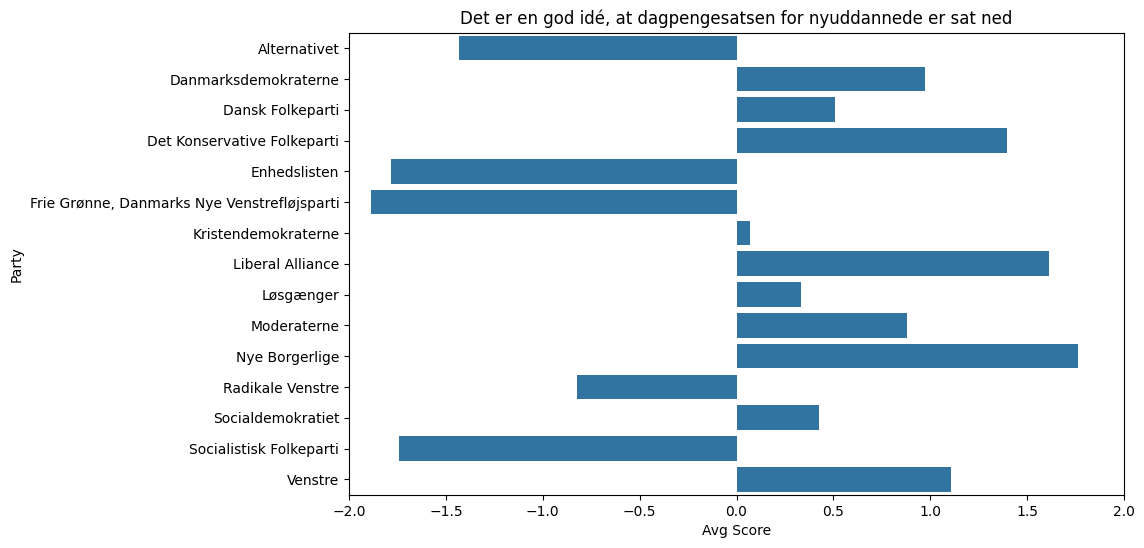

In [96]:
import seaborn as sns

party_avg = alldata.groupby('parti')[questions.columns].mean()

for idx in sorted_pca2.index:
    question_text = questions_text.loc[idx, 'Question']
    plt.figure(figsize=(10, 6))
    sns.barplot(y = party_avg.index, x = party_avg[questions.columns[idx]])
    plt.title(question_text)
    plt.ylabel("Party")
    plt.xlabel("Avg Score")
    plt.xlim([-2, 2])
    plt.show()

### Clustering

NameError: name 'X1' is not defined

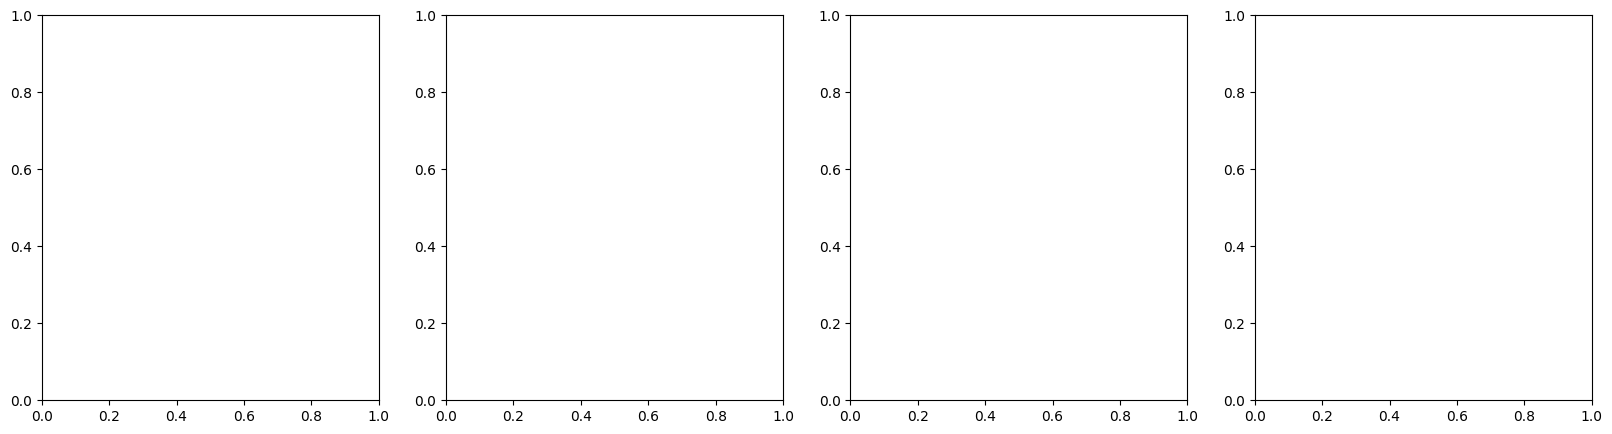

In [82]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

fig, axes = plt.subplots(1,4, figsize = (20,5))
for i, ax in enumerate(zip(axes.ravel())):
    X = eval("X" + str(i+1)) #this is bad style, but it works
    costs = []
    ks = range(2,10)
    for k in ks:
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(X)
        costs.append(kmeans.inertia_)
    ax[0].plot(ks,costs,'.-', markersize=10)
    ax[0].set_xlabel('k')
    ax[0].set_ylabel('Cost')
plt.show()